In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
from torch.utils.data import Dataset, DataLoader

In [2]:
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)
cars.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [3]:
X_list = cars.wt.values
X_np = np.array(X_list,dtype = np.float32).reshape(-1,1)
X = torch.from_numpy(X_np)

In [4]:
y_list = cars.mpg.values
y_np = np.array(y_list,dtype = np.float32).reshape(-1,1)
y_true = torch.from_numpy(y_np)

## **create a dataset and dataloader**

In [5]:
class LinearRegressionDataset(Dataset):
    # 3 important functions to define in this is 
    def __init__(self,X,y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):
        return self.X[idx],self.y[idx]

train_loader = DataLoader(LinearRegressionDataset(X_np,y_np),batch_size=2)

# model class

In [6]:
class LinearRegressionnTorch(nn.Module):
    def __init__(self,input_size,output_size):
        super(LinearRegressionnTorch,self).__init__()
        self.linear = nn.Linear(input_size,output_size)
    def forward(self,X):
        out = self.linear(X)
        return out
input_dim = 1
output_dim = 1
model = LinearRegressionnTorch(input_dim,output_dim)

## **Loss function**

In [7]:
loss_fun = nn.MSELoss()

## optimizer

In [8]:
LR = 0.01
optimizer = torch.optim.SGD(model.parameters(),lr=LR)

## check for trainloader 

In [9]:
# for i,(X,y) in enumerate(train_loader):
#     print(f"{i}th batch")
#     print(X)
#     print(y)

## TRAINING

In [10]:
# losses,slope,bias = [].[].[]
# BATCH_SIZE = 2
# num_epochs = 1000
# for i in range(num_epochs):
#     for i,(X,y) in enumerate(train_loader):    # set the gradient to zero
#             optimizer.zero_grad=0
    
#         # Forward pass
#             y_pred = model(X)
#         # compute loss 
#             loss = loss_fun(y_pred,y)
#         # Bacckward pass
#             loss.backward()
#         # update Weight
#             optimizer.step()
#         # get parameters
#             for name,param in model.named_parameters():
#                 if param.required_grad:
#                     if name == 'linear.weight':
#                         slope.append(param.data.numpy()[0][0])
#                             # 1. param.data extracts the underlying tensor values without history
#                             # 2. .numpy() converts the PyTorch tensor into a standard NumPy array
#                             #3.[0][0] extracts the single scalar value out of the 2D array matrix [[value]]
#                     if name == 'linear.bias':
#                             # 1. param.data.numpy() converts the tensor to a NumPy array
#                             # 2. [0] extracts the single scalar value out of the 1D array [value]
    #                         bias.append(param.data.numpy()[0])
    #             # store losses
    # losses.append(float(loss.data))
    #     # vizualise the loss
    # if i % 100 == 0:
    #     print("Epoch = {},loss:{:.4f}".format(i,loss.data))

In [11]:
# losses,slope,bias = [],[],[]
# BATCH_SIZE = 2
# num_epochs = 1000
# for i in range(num_epochs):
#     for i,(X,y) in enumerate(train_loader):    # set the gradient to zero
#         optimizer.zero_grad()
    
#         # Forward pass
#         y_pred = model(X)
#         # compute loss 
#         loss = loss_fun(y_pred,y)
#         # Bacckward pass
#         loss.backward()
#         # update Weight
#         optimizer.step()
        
#         # get parameters (FIXED INDENTATION TO SIT INSIDE THE BATCH LOOP)
#         for name,param in model.named_parameters():
#             if param.requires_grad:
    #             if name == 'linear.weight':
    #                 slope.append(param.data.numpy()[0][0])
    #                     # 1. param.data extracts the underlying tensor values without history
    #                     # 2. .numpy() converts the PyTorch tensor into a standard NumPy array
    #                     #3.[0][0] extracts the single scalar value out of the 2D array matrix [[value]]
    #             if name == 'linear.bias':
    #                     # 1. param.data.numpy() converts the tensor to a NumPy array
    #                     # 2. [0] extracts the single scalar value out of the 1D array [value]
    #                     bias.append(param.data.numpy()[0])
                        
    # # store losses (FIXED INDENTATION TO SIT INSIDE THE EPOCH LOOP)
    # losses.append(float(loss.data))
    # # vizualise the loss
    # if i % 100 == 0:
    #     print("Epoch = {},loss:{:.4f}".format(i,loss.data))


In [12]:
# Fixed syntax error in list initialization
losses, slope, bias = [], [], []
BATCH_SIZE = 2
num_epochs = 1000

for epoch in range(num_epochs):  # Renamed outer loop variable to 'epoch' to avoid conflict
    for X, y in train_loader:    # Removed redundant 'enumerate' since 'i' isn't used here
        # 1. Clear gradients properly
        optimizer.zero_grad()
    
        # 2. Forward pass
        y_pred = model(X)
        
        # 3. Compute loss 
        loss = loss_fun(y_pred, y)
        
        # 4. Backward pass
        loss.backward()
        
        # 5. Update Weights
        optimizer.step()
        
        # 6. Extract and store parameters (Corrected indentation)
        for name, param in model.named_parameters():
            if param.requires_grad:  # Fixed typo: 'requires_grad', not 'required_grad'
                if name == 'linear.weight':
                    slope.append(param.data.numpy()[0][0])
                if name == 'linear.bias':
                    bias.append(param.data.numpy()[0])
                    
    # 7. Store loss after the batch loop finishes (Corrected indentation)
    losses.append(float(loss.item()))  # Best practice: use .item() instead of .data
    
    # 8. Visualise the loss (Uses 'epoch' variable to avoid confusion)
    if epoch % 100 == 0:
        print("Epoch = {}, loss: {:.4f}".format(epoch, loss.item()))


Epoch = 0, loss: 27.4843
Epoch = 100, loss: 4.5785
Epoch = 200, loss: 3.9644
Epoch = 300, loss: 3.9211
Epoch = 400, loss: 3.9173
Epoch = 500, loss: 3.9170
Epoch = 600, loss: 3.9169
Epoch = 700, loss: 3.9169
Epoch = 800, loss: 3.9169
Epoch = 900, loss: 3.9169


<Axes: >

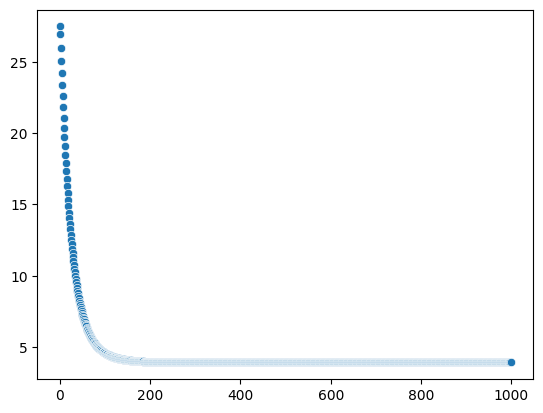

In [13]:
sns.scatterplot(x=range(len(losses)),y=losses)

<Axes: >

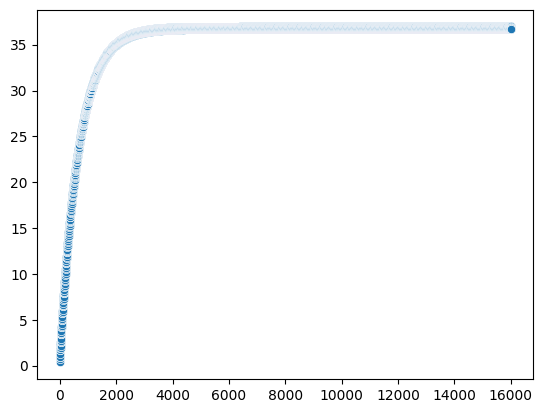

In [14]:
sns.scatterplot(x=range(len(bias)),y=bias)

<Axes: >

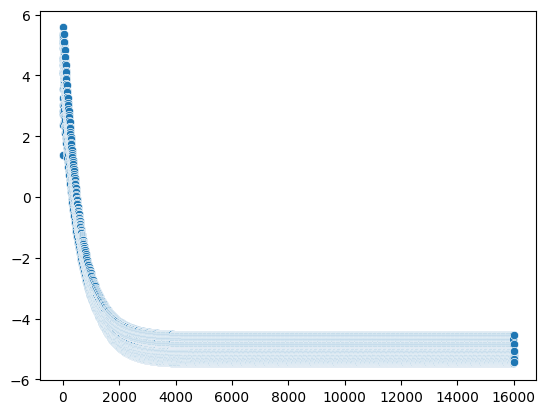

In [15]:
sns.scatterplot(x=range(len(slope)),y=slope)